Step 1: Upload and load master Excel file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Master_ML_Datasheet.xlsx to Master_ML_Datasheet (1).xlsx


In [ ]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (46656, 13)


,Nt,x,Na,Absorber_thickness,ETL_Abs_interface,HTL_Abs_interface,T,Rs,Rsh,Voc,Jsc,FF,PCE
0,1000000000000,3.55,10000000000000000,0.3,10000000000,10000000000,300,0,1000,1.633174,14.281771,79.4562,18.5328
1,1000000000000,3.55,10000000000000000,0.3,10000000000,100000000000,300,0,1000,1.624512,14.281770,79.8156,18.5180
2,1000000000000,3.55,10000000000000000,0.3,10000000000,1000000000000,300,0,1000,1.592175,14.281762,80.8621,18.3873
3,1000000000000,3.55,10000000000000000,0.3,100000000000,10000000000,300,0,1000,1.594002,14.281767,80.7601,18.3852
4,1000000000000,3.55,10000000000000000,0.3,100000000000,100000000000,300,0,1000,1.591441,14.281766,80.8534,18.3768


Step 2: Check final column headings

In [ ]:
df.columns

Index(['Nt', 'x', 'Na', 'Absorber_thickness', 'ETL_Abs_interface',
       'HTL_Abs_interface', 'T', 'Rs', 'Rsh', 'Voc', 'Jsc', 'FF', 'PCE'],
      dtype='object')

In [ ]:
['Nt', 'x', 'Na', 'Absorber_thickness', 'ETL_Abs_interface',
 'HTL_Abs_interface', 'T', 'Rs', 'Rsh',
 'Voc', 'Jsc', 'FF', 'PCE']

['Nt',
 'x',
 'Na',
 'Absorber_thickness',
 'ETL_Abs_interface',
 'HTL_Abs_interface',
 'T',
 'Rs',
 'Rsh',
 'Voc',
 'Jsc',
 'FF',
 'PCE']

In [ ]:
features = [
    'Nt',
    'x',
    'Na',
    'Absorber_thickness',
    'ETL_Abs_interface',
    'HTL_Abs_interface',
    'T',
    'Rs',
    'Rsh'
]

targets = ['Voc', 'Jsc', 'FF', 'PCE']

Step 3: Dataset quality check

In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (46656, 13)

Missing values in each column:
Nt                    0
x                     0
Na                    0
Absorber_thickness    0
ETL_Abs_interface     0
HTL_Abs_interface     0
T                     0
Rs                    0
Rsh                   0
Voc                   0
Jsc                   0
FF                    0
PCE                   0
dtype: int64

Duplicate rows:
0

Data types:
Nt                      int64
x                     float64
Na                     uint64
Absorber_thickness    float64
ETL_Abs_interface       int64
HTL_Abs_interface       int64
T                       int64
Rs                      int64
Rsh                     int64
Voc                   float64
Jsc                   float64
FF                    float64
PCE                   float64
dtype: object


Step 4: Check input values

In [ ]:
for col in features:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))


Nt:
[np.int64(1000000000000), np.int64(10000000000000), np.int64(100000000000000), np.int64(10000000000000000)]

x:
[np.float64(3.55), np.float64(3.58), np.float64(3.61)]

Na:
[np.uint64(10000000000000000), np.uint64(100000000000000000), np.uint64(1000000000000000000), np.uint64(10000000000000000000)]

Absorber_thickness:
[np.float64(0.3), np.float64(0.5), np.float64(0.6), np.float64(0.8)]

ETL_Abs_interface:
[np.int64(10000000000), np.int64(100000000000), np.int64(1000000000000)]

HTL_Abs_interface:
[np.int64(10000000000), np.int64(100000000000), np.int64(1000000000000)]

T:
[np.int64(300), np.int64(325), np.int64(350)]

Rs:
[np.int64(0), np.int64(2), np.int64(5)]

Rsh:
[np.int64(1000), np.int64(10000), np.int64(100000)]


Step 5: Check output ranges

In [ ]:
df[targets].describe()

,Voc,Jsc,FF,PCE
count,46656.000000,46656.000000,46656.000000,46656.000000
mean,1.472820,15.521566,82.232339,18.980154
std,0.106823,2.224952,5.865371,4.097160
min,1.170319,10.169574,64.550900,10.348900
25%,1.417226,14.208737,78.439775,15.557100
50%,1.495772,16.519301,82.939350,20.146200
75%,1.548009,17.205658,87.124750,22.200700
max,1.669613,17.960933,91.861800,27.232000


In [ ]:
for col in targets:
    print(f"{col}: Min = {df[col].min():.4f}, Max = {df[col].max():.4f}, Mean = {df[col].mean():.4f}")

Voc: Min = 1.1703, Max = 1.6696, Mean = 1.4728
Jsc: Min = 10.1696, Max = 17.9609, Mean = 15.5216
FF: Min = 64.5509, Max = 91.8618, Mean = 82.2323
PCE: Min = 10.3489, Max = 27.2320, Mean = 18.9802


In [ ]:
Step 6: Apply log transformation

In [ ]:
df_ml = df.copy()

log_features = ['Nt', 'Na', 'ETL_Abs_interface', 'HTL_Abs_interface', 'Rsh']

for col in log_features:
    df_ml[col] = np.log10(df_ml[col])

df_ml.head()

,Nt,x,Na,Absorber_thickness,ETL_Abs_interface,HTL_Abs_interface,T,Rs,Rsh,Voc,Jsc,FF,PCE
0,12.0,3.55,16.0,0.3,10.0,10.0,300,0,3.0,1.633174,14.281771,79.4562,18.5328
1,12.0,3.55,16.0,0.3,10.0,11.0,300,0,3.0,1.624512,14.281770,79.8156,18.5180
2,12.0,3.55,16.0,0.3,10.0,12.0,300,0,3.0,1.592175,14.281762,80.8621,18.3873
3,12.0,3.55,16.0,0.3,11.0,10.0,300,0,3.0,1.594002,14.281767,80.7601,18.3852
4,12.0,3.55,16.0,0.3,11.0,11.0,300,0,3.0,1.591441,14.281766,80.8534,18.3768


Step 7: Correlation analysis

In [ ]:
corr = df_ml[features + targets].corr()

corr

,Nt,x,Na,Absorber_thickness,ETL_Abs_interface,HTL_Abs_interface,T,Rs,Rsh,Voc,Jsc,FF,PCE
Nt,1.000000e+00,-1.013226e-15,2.461396e-16,-2.506018e-17,-4.702378e-17,-5.971374e-17,1.133288e-14,5.094037e-15,-9.509587e-16,-0.803416,-0.635464,-0.534287,-0.827593
x,-1.013226e-15,1.000000e+00,-9.953585e-15,-1.812613e-15,-5.627738e-17,1.706986e-17,-1.763245e-13,-6.880150e-14,-3.324938e-14,0.032613,-0.001998,0.007387,0.012541
Na,2.461396e-16,-9.953585e-15,1.000000e+00,3.485866e-16,-3.828741e-17,-1.350028e-15,2.637750e-14,8.068160e-15,8.215319e-16,0.354371,-0.235043,0.283378,0.057558
Absorber_thickness,-2.506018e-17,-1.812613e-15,3.485866e-16,1.000000e+00,-3.811332e-16,-1.928380e-16,6.286093e-15,2.392671e-15,-1.872040e-17,-0.025194,0.449626,-0.030437,0.292726
ETL_Abs_interface,-4.702378e-17,-5.627738e-17,-3.828741e-17,-3.811332e-16,1.000000e+00,-1.537693e-17,-4.226437e-14,-1.288571e-14,1.287293e-15,-0.144446,-0.000002,-0.000726,-0.052018
HTL_Abs_interface,-5.971374e-17,1.706986e-17,-1.350028e-15,-1.928380e-16,-1.537693e-17,1.000000e+00,-6.030105e-14,-1.079622e-14,-5.381098e-15,-0.029847,-0.003952,0.008854,-0.010297
T,1.133288e-14,-1.763245e-13,2.637750e-14,6.286093e-15,-4.226437e-14,-6.030105e-14,1.000000e+00,-1.372050e-14,-1.100088e-14,-0.250995,0.012025,-0.005440,-0.076484
Rs,5.094037e-15,-6.880150e-14,8.068160e-15,2.392671e-15,-1.288571e-14,-1.079622e-14,-1.372050e-14,1.000000e+00,5.085530e-15,0.022890,-0.006522,-0.320262,-0.104190
Rsh,-9.509587e-16,-3.324938e-14,8.215319e-16,-1.872040e-17,1.287293e-15,-5.381098e-15,-1.100088e-14,5.085530e-15,1.000000e+00,0.014516,0.004891,0.424398,0.144212
Voc,-8.034158e-01,3.261350e-02,3.543711e-01,-2.519411e-02,-1.444461e-01,-2.984688e-02,-2.509954e-01,2.289008e-02,1.451556e-02,1.000000,0.356762,0.626053,0.739884


In [ ]:
# Corrected Cell 47
# Use final predictions already generated in Cell 45
# Do not retrain smaller models here

import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Best target-specific model selection based on Cell 45 test results
best_predictions = {
    "Voc": all_predictions["RFR"]["Voc"],
    "Jsc": all_predictions["RFR"]["Jsc"],
    "FF": all_predictions["RFR"]["FF"],
    "PCE": all_predictions["XGBR"]["PCE"]
}

best_model_names = {
    "Voc": "RFR",
    "Jsc": "RFR",
    "FF": "RFR",
    "PCE": "XGBR"
}

# Recalculate best-model test performance
best_test_results = []

for target in ["Voc", "Jsc", "FF", "PCE"]:
    y_actual = Y_test[target].values
    y_pred = best_predictions[target]

    best_test_results.append({
        "Target": target,
        "Best_Model": best_model_names[target],
        "Test_R2": r2_score(y_actual, y_pred),
        "Test_MAE": mean_absolute_error(y_actual, y_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_actual, y_pred))
    })

best_test_results_df = pd.DataFrame(best_test_results).round(5)
best_test_results_df

,Target,Best_Model,Test_R2,Test_MAE,Test_RMSE
0,Voc,RFR,0.99995,0.00041,0.00073
1,Jsc,RFR,1.00000,0.00063,0.00243
2,FF,RFR,0.99984,0.03732,0.07380
3,PCE,XGBR,0.99993,0.02682,0.03465


Step 8: Draw correlation heatmap

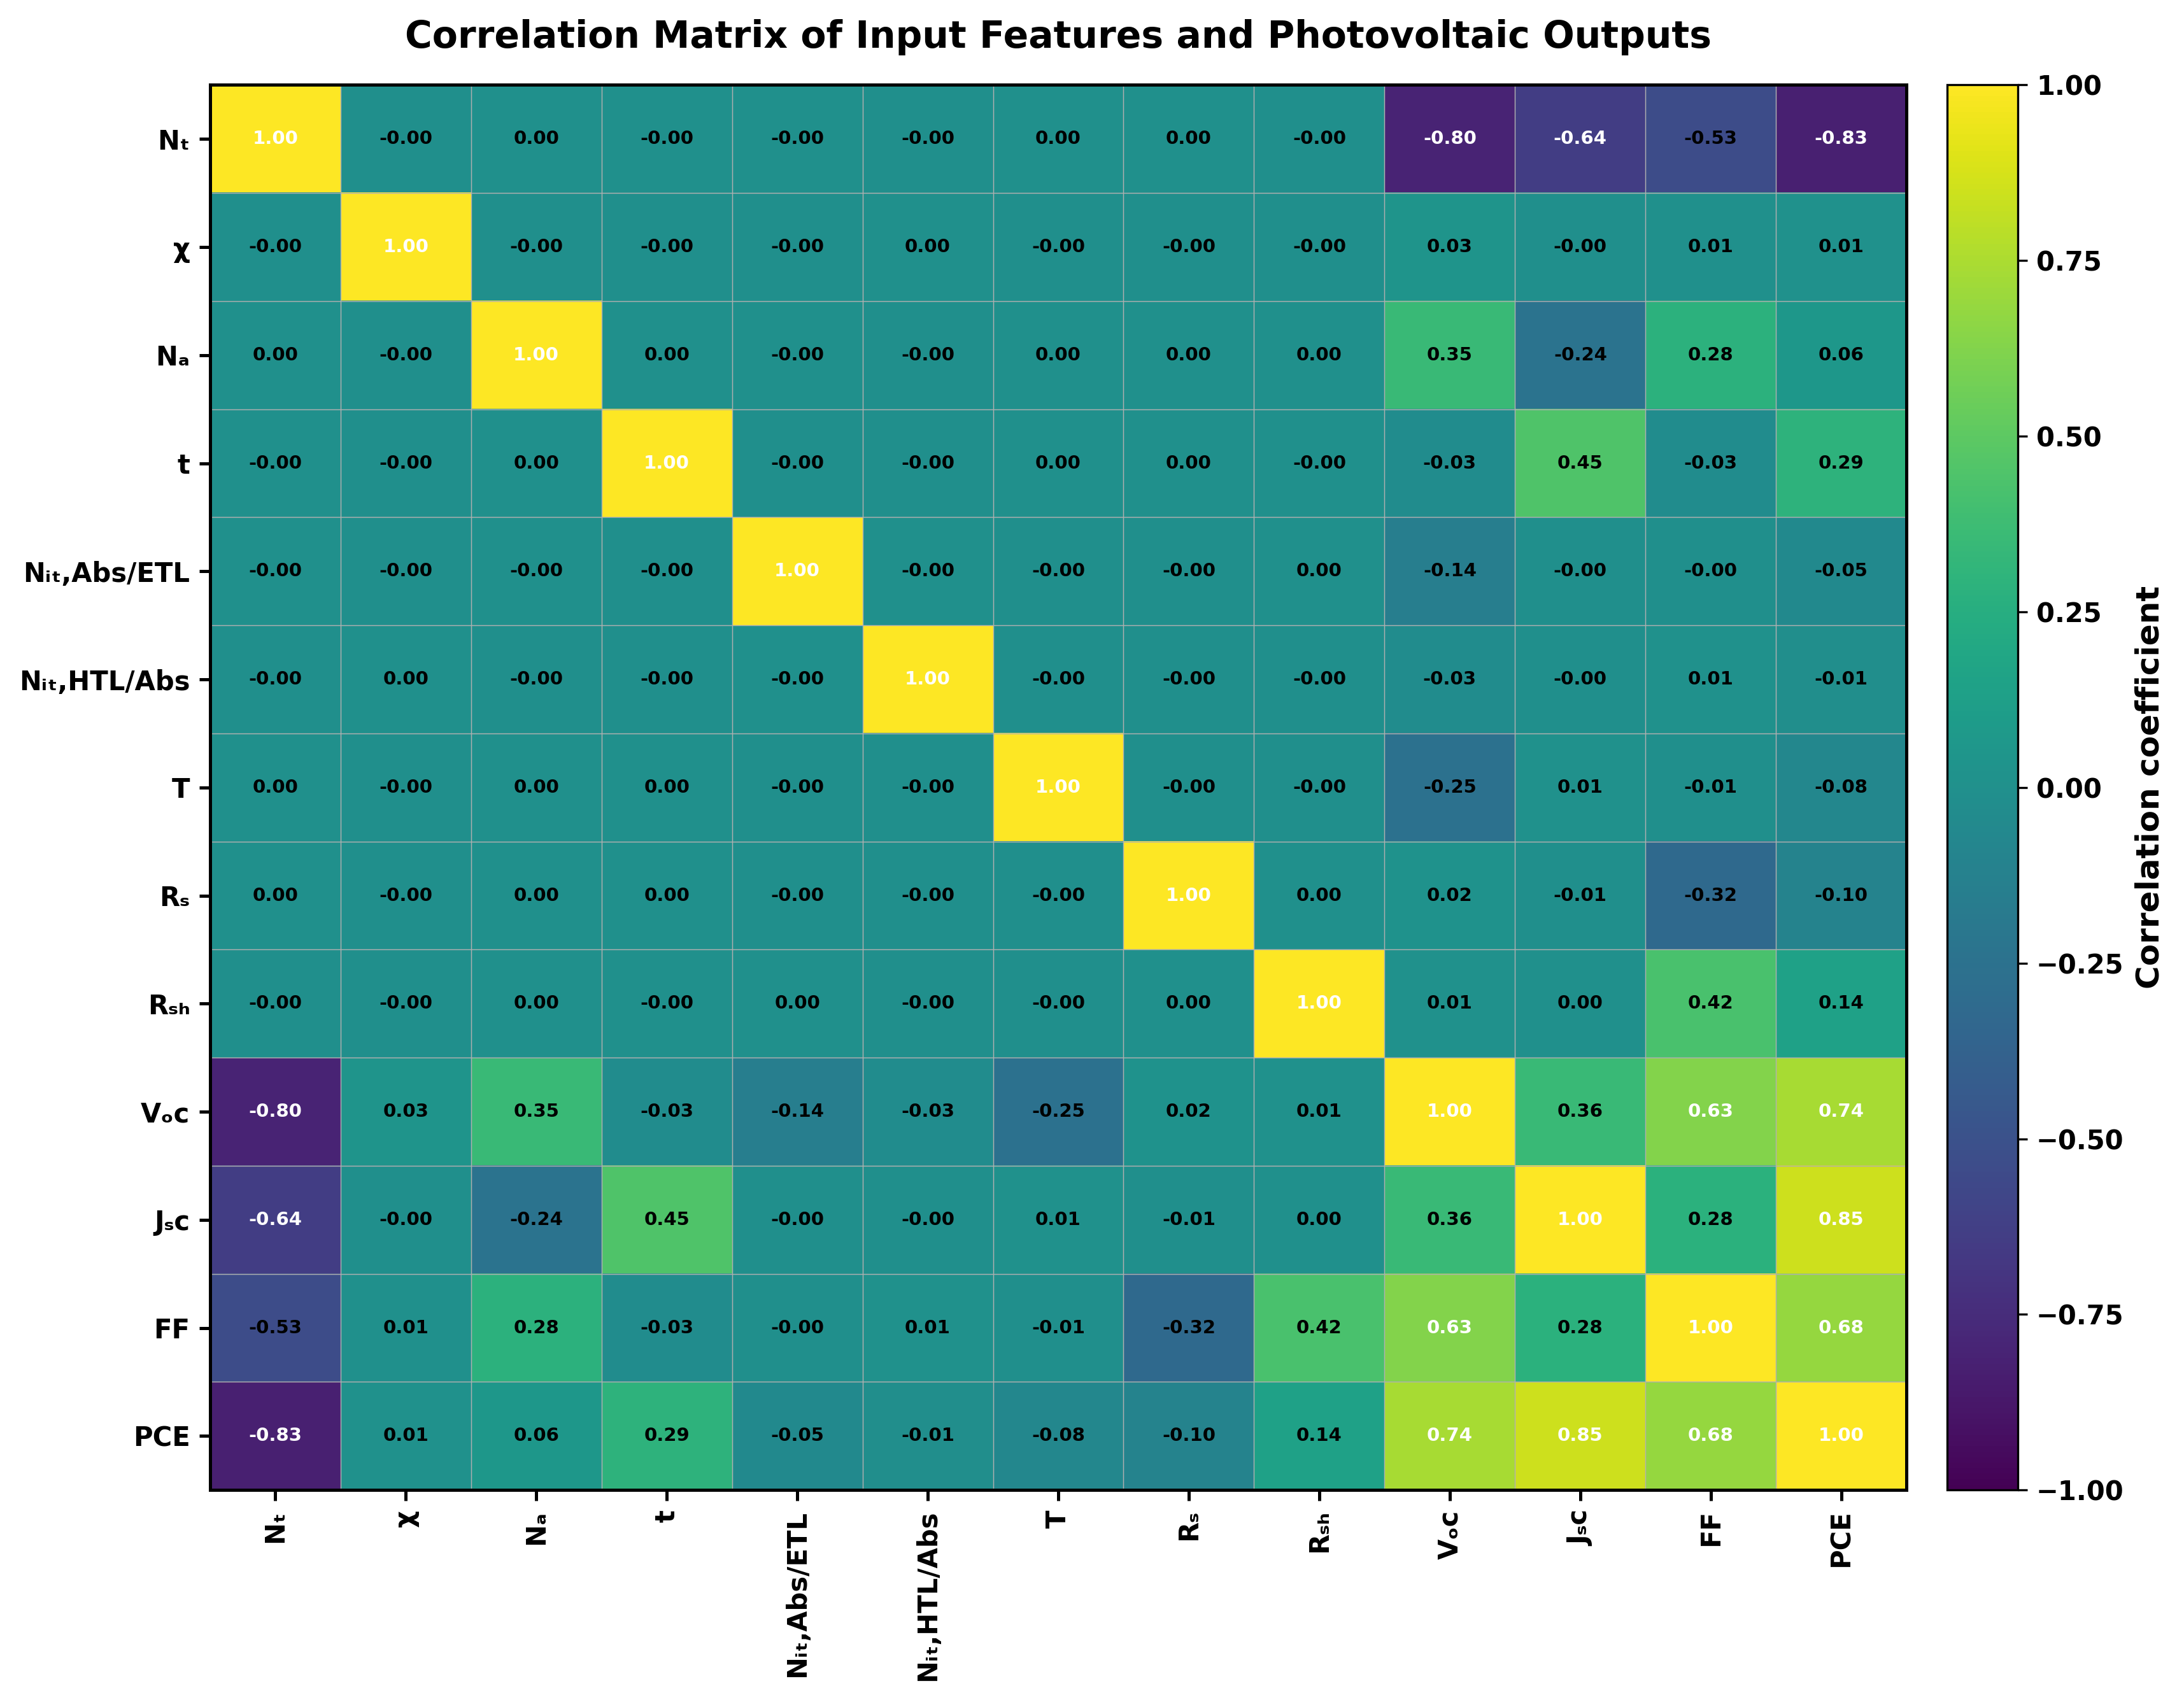

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Rename labels only for figure display
display_labels = {
    'Nt': 'Nₜ',
    'x': 'χ',
    'Na': 'Nₐ',
    'Absorber_thickness': 't',
    'ETL_Abs_interface': 'Nᵢₜ,Abs/ETL',
    'HTL_Abs_interface': 'Nᵢₜ,HTL/Abs',
    'T': 'T',
    'Rs': 'Rₛ',
    'Rsh': 'Rₛₕ',
    'Voc': 'Vₒc',
    'Jsc': 'Jₛc',
    'FF': 'FF',
    'PCE': 'PCE'
}

corr_display = corr.copy()
corr_display.index = [display_labels[col] for col in corr_display.index]
corr_display.columns = [display_labels[col] for col in corr_display.columns]

# Create figure
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

im = ax.imshow(
    corr_display,
    aspect='auto',
    vmin=-1,
    vmax=1
)

# Color bar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(
    'Correlation coefficient',
    fontsize=12,
    fontweight='bold'
)

# Make color-bar tick labels bold
for tick in cbar.ax.get_yticklabels():
    tick.set_fontsize(10)
    tick.set_fontweight('bold')

# Axis ticks and labels
ax.set_xticks(np.arange(len(corr_display.columns)))
ax.set_yticks(np.arange(len(corr_display.index)))

ax.set_xticklabels(
    corr_display.columns,
    rotation=90,
    fontsize=10,
    fontweight='bold'
)

ax.set_yticklabels(
    corr_display.index,
    fontsize=10,
    fontweight='bold'
)

# Add correlation values inside each cell
for i in range(len(corr_display.index)):
    for j in range(len(corr_display.columns)):
        value = corr_display.iloc[i, j]

        # Improve visibility depending on cell intensity
        text_color = 'white' if abs(value) > 0.55 else 'black'

        ax.text(
            j,
            i,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=7,
            fontweight='bold',
            color=text_color
        )

# Title
ax.set_title(
    'Correlation Matrix of Input Features and Photovoltaic Outputs',
    fontsize=14,
    fontweight='bold',
    pad=14
)

# Improve axis border thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Cell boundaries for clearer presentation
ax.set_xticks(np.arange(-0.5, len(corr_display.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(corr_display.index), 1), minor=True)
ax.grid(which='minor', linewidth=0.35)
ax.tick_params(which='minor', bottom=False, left=False)

ax.tick_params(
    axis='both',
    which='major',
    width=1.2,
    length=4
)

plt.tight_layout()

plt.savefig(
    'Correlation_Matrix_ML.png',
    dpi=1200,
    bbox_inches='tight'
)

plt.show()

In [ ]:
pce_corr = corr['PCE'].sort_values(ascending=False)
print(pce_corr)

PCE                   1.000000
Jsc                   0.848173
Voc                   0.739884
FF                    0.683386
Absorber_thickness    0.292726
Rsh                   0.144212
Na                    0.057558
x                     0.012541
HTL_Abs_interface    -0.010297
ETL_Abs_interface    -0.052018
T                    -0.076484
Rs                   -0.104190
Nt                   -0.827593
Name: PCE, dtype: float64


In [ ]:
df_ml.to_excel("Preprocessed_ML_Dataset.xlsx", index=False)

files.download("Preprocessed_ML_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.shape
df[targets].describe()
pce_corr

,PCE
PCE,1.000000
Jsc,0.848173
Voc,0.739884
FF,0.683386
Absorber_thickness,0.292726
Rsh,0.144212
Na,0.057558
x,0.012541
HTL_Abs_interface,-0.010297
ETL_Abs_interface,-0.052018


## 5.3.1 Import Required Libraries

This step imports the required machine-learning models, cross-validation tools, preprocessing functions, and regression-performance metrics.

In [ ]:
# Import required libraries for ML model development and validation

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

## 5.3.2 Define Input Features and Target Outputs

The nine preprocessed device parameters are used as input features, while Voc, Jsc, FF, and PCE are treated as regression targets.

In [ ]:
# Define input features and photovoltaic target outputs

features = [
    'Nt',
    'x',
    'Na',
    'Absorber_thickness',
    'ETL_Abs_interface',
    'HTL_Abs_interface',
    'T',
    'Rs',
    'Rsh'
]

targets = ['Voc', 'Jsc', 'FF', 'PCE']

X = df_ml[features]
Y = df_ml[targets]

print("Input feature shape:", X.shape)
print("Output target shape:", Y.shape)

X.head()

Input feature shape: (46656, 9)
Output target shape: (46656, 4)


,Nt,x,Na,Absorber_thickness,ETL_Abs_interface,HTL_Abs_interface,T,Rs,Rsh
0,12.0,3.55,16.0,0.3,10.0,10.0,300,0,3.0
1,12.0,3.55,16.0,0.3,10.0,11.0,300,0,3.0
2,12.0,3.55,16.0,0.3,10.0,12.0,300,0,3.0
3,12.0,3.55,16.0,0.3,11.0,10.0,300,0,3.0
4,12.0,3.55,16.0,0.3,11.0,11.0,300,0,3.0


## 5.3.3 Train-Test Split

The preprocessed dataset is divided into training and testing subsets using an 80:20 ratio. The test set is kept unseen during model training.

In [ ]:
# Split dataset into training and testing subsets

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (37324, 9)
X_test shape: (9332, 9)
Y_train shape: (37324, 4)
Y_test shape: (9332, 4)


## 5.3.4 Define Machine-Learning Models

Four supervised regression models are defined: Linear Regression, Random Forest Regressor, Extreme Gradient Boosting Regressor, and Artificial Neural Network.

In [ ]:
# Define ML regression models

models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "RFR": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBR": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42,
            early_stopping=True
        ))
    ])
}

print("Defined models:", list(models.keys()))

Defined models: ['LR', 'RFR', 'XGBR', 'ANN']


## 5.3.5 Define Fivefold Cross-Validation and Metrics

Fivefold cross-validation is applied to the training dataset. Model performance is evaluated using R², MAE, and RMSE.

In [ ]:
# Define fivefold cross-validation strategy

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define evaluation metrics
scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

## 5.3.6 Cross-Validation for All Models and Targets

Each model is trained and validated separately for Voc, Jsc, FF, and PCE using fivefold cross-validation.

In [ ]:
# Run fivefold cross-validation for each model and each target

cv_results = []

for target in targets:
    y_train_target = Y_train[target]

    for model_name, model in models.items():

        scores = cross_validate(
            model,
            X_train,
            y_train_target,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        cv_results.append({
            "Target": target,
            "Model": model_name,
            "CV_R2_mean": scores["test_R2"].mean(),
            "CV_R2_std": scores["test_R2"].std(),
            "CV_MAE_mean": -scores["test_MAE"].mean(),
            "CV_MAE_std": scores["test_MAE"].std(),
            "CV_RMSE_mean": -scores["test_RMSE"].mean(),
            "CV_RMSE_std": scores["test_RMSE"].std()
        })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Target,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Voc,LR,0.859072,3.668856e-03,0.031935,0.000206,0.040194,0.000304
1,Voc,RFR,0.999932,1.128989e-06,0.000501,0.000003,0.000884,0.000009
2,Voc,XGBR,0.999800,4.902978e-06,0.001116,0.000009,0.001515,0.000005
3,Voc,ANN,0.999196,2.613825e-04,0.002334,0.000369,0.002995,0.000461
4,Jsc,LR,0.659050,8.432279e-03,1.032020,0.010103,1.297977,0.013659
5,Jsc,RFR,0.999997,4.926998e-07,0.001043,0.000055,0.003878,0.000322
6,Jsc,XGBR,0.999998,2.896224e-07,0.002518,0.000172,0.003450,0.000215
7,Jsc,ANN,0.999588,9.660313e-05,0.035163,0.004430,0.044833,0.005368
8,FF,LR,0.647878,1.008113e-02,2.684276,0.022110,3.472099,0.033713
9,FF,RFR,0.999772,6.159909e-06,0.045675,0.000790,0.088315,0.000965


## 5.3.7 Cross-Validation Summary

The cross-validation results are rounded for clear comparison and manuscript reporting.

In [ ]:
# Round cross-validation results for clear display

cv_results_display = cv_results_df.copy()

cols_to_round = [
    "CV_R2_mean",
    "CV_R2_std",
    "CV_MAE_mean",
    "CV_MAE_std",
    "CV_RMSE_mean",
    "CV_RMSE_std"
]

for col in cols_to_round:
    cv_results_display[col] = cv_results_display[col].round(5)

cv_results_display

,Target,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Voc,LR,0.85907,0.00367,0.03194,0.00021,0.04019,0.00030
1,Voc,RFR,0.99993,0.00000,0.00050,0.00000,0.00088,0.00001
2,Voc,XGBR,0.99980,0.00000,0.00112,0.00001,0.00152,0.00001
3,Voc,ANN,0.99920,0.00026,0.00233,0.00037,0.00299,0.00046
4,Jsc,LR,0.65905,0.00843,1.03202,0.01010,1.29798,0.01366
5,Jsc,RFR,1.00000,0.00000,0.00104,0.00006,0.00388,0.00032
6,Jsc,XGBR,1.00000,0.00000,0.00252,0.00017,0.00345,0.00021
7,Jsc,ANN,0.99959,0.00010,0.03516,0.00443,0.04483,0.00537
8,FF,LR,0.64788,0.01008,2.68428,0.02211,3.47210,0.03371
9,FF,RFR,0.99977,0.00001,0.04568,0.00079,0.08832,0.00097


## 5.3.8 Save Cross-Validation Results

The cross-validation results are saved as an Excel file for manuscript preparation.

In [ ]:
# Save cross-validation results

cv_results_display.to_excel("ML_Cross_Validation_Results.xlsx", index=False)

from google.colab import files
files.download("ML_Cross_Validation_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5.4.1 Test-Set Evaluation of Final ML Models

The trained models are evaluated on the unseen test dataset using R², MAE, and RMSE.

In [ ]:
# Function for final test-set evaluation

def evaluate_model_test(model, model_name, X_train, X_test, Y_train, Y_test, targets):
    results = []
    predictions = {}

    for target in targets:
        print(f"Training and testing {model_name} for {target}...")

        y_train_target = Y_train[target]
        y_test_target = Y_test[target]

        model.fit(X_train, y_train_target)
        y_pred = model.predict(X_test)

        predictions[target] = y_pred

        results.append({
            "Target": target,
            "Model": model_name,
            "Test_R2": r2_score(y_test_target, y_pred),
            "Test_MAE": mean_absolute_error(y_test_target, y_pred),
            "Test_RMSE": np.sqrt(mean_squared_error(y_test_target, y_pred))
        })

    return pd.DataFrame(results), predictions

## 5.4.2 Define Final Models

The same LR, RFR, XGBR, and ANN models are used for final test-set evaluation.

In [ ]:
final_models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "RFR": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBR": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64, 32),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.10
        ))
    ])
}

## 5.4.3 Run Test-Set Evaluation

Each trained model is evaluated on the unseen test dataset.

In [ ]:
test_results_all = []
all_predictions = {}

for model_name, model in final_models.items():
    test_df, preds = evaluate_model_test(
        model,
        model_name,
        X_train,
        X_test,
        Y_train,
        Y_test,
        targets
    )

    test_results_all.append(test_df)
    all_predictions[model_name] = preds

test_results_df = pd.concat(test_results_all, ignore_index=True)
test_results_display = test_results_df.round(5)

test_results_display

Training and testing LR for Voc...
Training and testing LR for Jsc...
Training and testing LR for FF...
Training and testing LR for PCE...
Training and testing RFR for Voc...
Training and testing RFR for Jsc...
Training and testing RFR for FF...
Training and testing RFR for PCE...
Training and testing XGBR for Voc...
Training and testing XGBR for Jsc...
Training and testing XGBR for FF...
Training and testing XGBR for PCE...
Training and testing ANN for Voc...
Training and testing ANN for Jsc...
Training and testing ANN for FF...
Training and testing ANN for PCE...


,Target,Model,Test_R2,Test_MAE,Test_RMSE
0,Voc,LR,0.85406,0.03200,0.04038
1,Jsc,LR,0.66991,1.01797,1.28194
2,FF,LR,0.65477,2.68166,3.47591
3,PCE,LR,0.81726,1.43278,1.75814
4,Voc,RFR,0.99995,0.00041,0.00073
5,Jsc,RFR,1.00000,0.00063,0.00243
6,FF,RFR,0.99984,0.03732,0.07380
7,PCE,RFR,0.99981,0.03149,0.05702
8,Voc,XGBR,0.99981,0.00107,0.00145
9,Jsc,XGBR,1.00000,0.00213,0.00298


Figure 1: Combined Actual-vs-Predicted Plot

In [ ]:
# Create best_predictions dictionary before plotting

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

best_models = {
    "Voc": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "Jsc": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "FF": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "PCE": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

best_predictions = {}
best_test_results = []

for target, model in best_models.items():
    print(f"Training best model for {target}...")

    model.fit(X_train, Y_train[target])
    y_pred = model.predict(X_test)

    best_predictions[target] = y_pred

    best_test_results.append({
        "Target": target,
        "Best_Model": "RFR" if target in ["Voc", "Jsc", "FF"] else "XGBR",
        "Test_R2": r2_score(Y_test[target], y_pred),
        "Test_MAE": mean_absolute_error(Y_test[target], y_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred))
    })

best_test_results_df = pd.DataFrame(best_test_results).round(5)
best_test_results_df

Training best model for Voc...
Training best model for Jsc...
Training best model for FF...
Training best model for PCE...


,Target,Best_Model,Test_R2,Test_MAE,Test_RMSE
0,Voc,RFR,0.99966,0.00119,0.00196
1,Jsc,RFR,0.99999,0.00243,0.00570
2,FF,RFR,0.99910,0.10884,0.17794
3,PCE,XGBR,0.99860,0.10019,0.15397


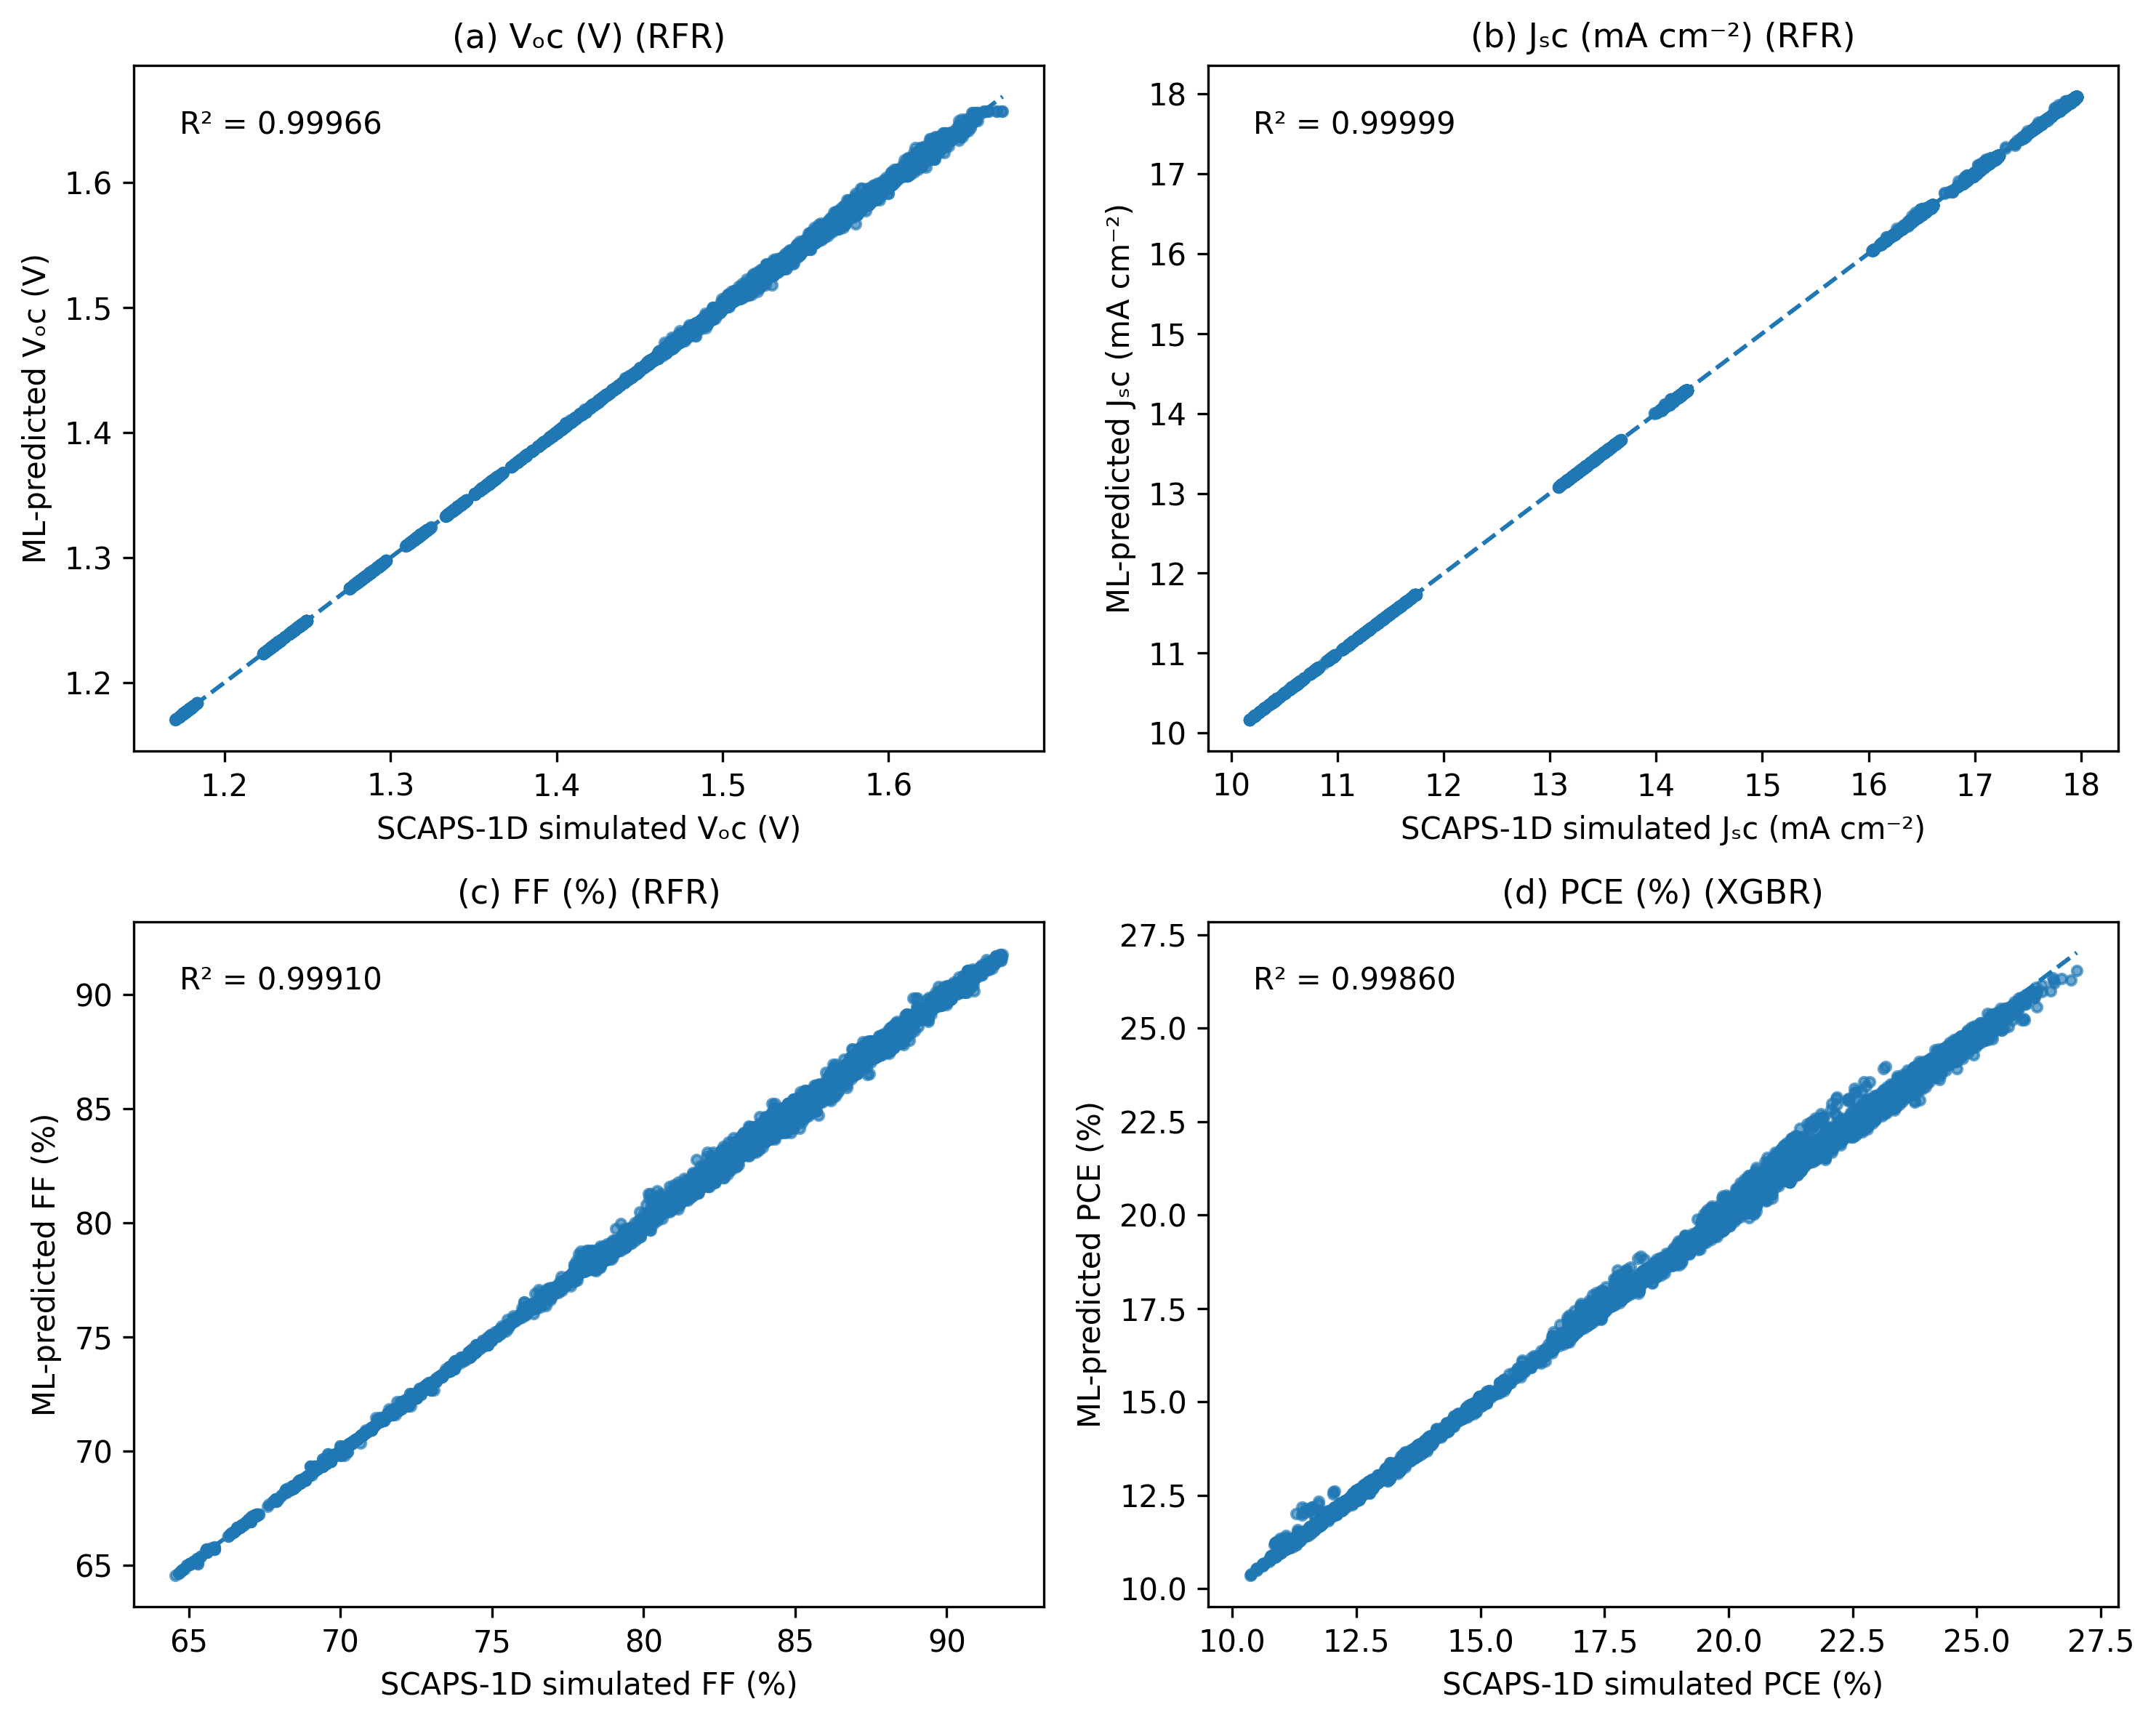

In [ ]:
# Combined actual-vs-predicted plot for best-performing models

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

target_labels = {
    "Voc": "Vₒc (V)",
    "Jsc": "Jₛc (mA cm⁻²)",
    "FF": "FF (%)",
    "PCE": "PCE (%)"
}

model_labels = {
    "Voc": "RFR",
    "Jsc": "RFR",
    "FF": "RFR",
    "PCE": "XGBR"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)
axes = axes.flatten()

for i, target in enumerate(targets):
    ax = axes[i]

    y_actual = Y_test[target]
    y_pred = best_predictions[target]
    r2 = r2_score(y_actual, y_pred)

    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())

    ax.scatter(y_actual, y_pred, s=10, alpha=0.65)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.4)

    ax.set_xlabel(f"SCAPS-1D simulated {target_labels[target]}", fontsize=10)
    ax.set_ylabel(f"ML-predicted {target_labels[target]}", fontsize=10)
    ax.set_title(f"({chr(97+i)}) {target_labels[target]} ({model_labels[target]})", fontsize=11)

    ax.text(
        0.05, 0.90,
        f"R² = {r2:.5f}",
        transform=ax.transAxes,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Fig_Actual_vs_Predicted_Best_Models.png", dpi=1200, bbox_inches="tight")
plt.show()

In [ ]:
# Create Origin-ready actual vs predicted datasheet

origin_plot_data = pd.DataFrame({
    "Voc_SCAPS": Y_test["Voc"].values,
    "Voc_ML_RFR": best_predictions["Voc"],

    "Jsc_SCAPS": Y_test["Jsc"].values,
    "Jsc_ML_RFR": best_predictions["Jsc"],

    "FF_SCAPS": Y_test["FF"].values,
    "FF_ML_RFR": best_predictions["FF"],

    "PCE_SCAPS": Y_test["PCE"].values,
    "PCE_ML_XGBR": best_predictions["PCE"]
})

origin_plot_data.head()

,Voc_SCAPS,Voc_ML_RFR,Jsc_SCAPS,Jsc_ML_RFR,FF_SCAPS,FF_ML_RFR,PCE_SCAPS,PCE_ML_XGBR
0,1.415535,1.415435,16.548724,16.547416,86.1641,86.112308,20.1842,20.086271
1,1.344439,1.344435,13.139624,13.139364,74.7888,74.774299,13.2118,13.207826
2,1.644134,1.650420,17.923221,17.921860,82.1230,81.614639,24.2001,23.887400
3,1.246408,1.246369,13.642558,13.639866,74.3174,74.164257,12.6371,12.685656
4,1.528864,1.529200,14.274821,14.276185,84.4826,84.244465,18.4377,18.600733


In [ ]:
origin_plot_data.to_excel("Origin_Actual_vs_Predicted_Data.xlsx", index=False)

from google.colab import files
files.download("Origin_Actual_vs_Predicted_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 18: SHAP Analysis for PCE Prediction

SHAP analysis is performed using the XGBR model because it achieved the best prediction accuracy for PCE.

In [ ]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

xgbr_pce_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgbr_pce_model.fit(X_train, Y_train["PCE"])

pce_pred = xgbr_pce_model.predict(X_test)

print("PCE Test R2:", r2_score(Y_test["PCE"], pce_pred))
print("PCE Test MAE:", mean_absolute_error(Y_test["PCE"], pce_pred))
print("PCE Test RMSE:", np.sqrt(mean_squared_error(Y_test["PCE"], pce_pred)))

PCE Test R2: 0.9999290351670668
PCE Test MAE: 0.026824207782213946
PCE Test RMSE: 0.03464671469228917


## Step 19: SHAP Summary Plot

The SHAP summary plot is generated to identify the most influential input features controlling PCE prediction.

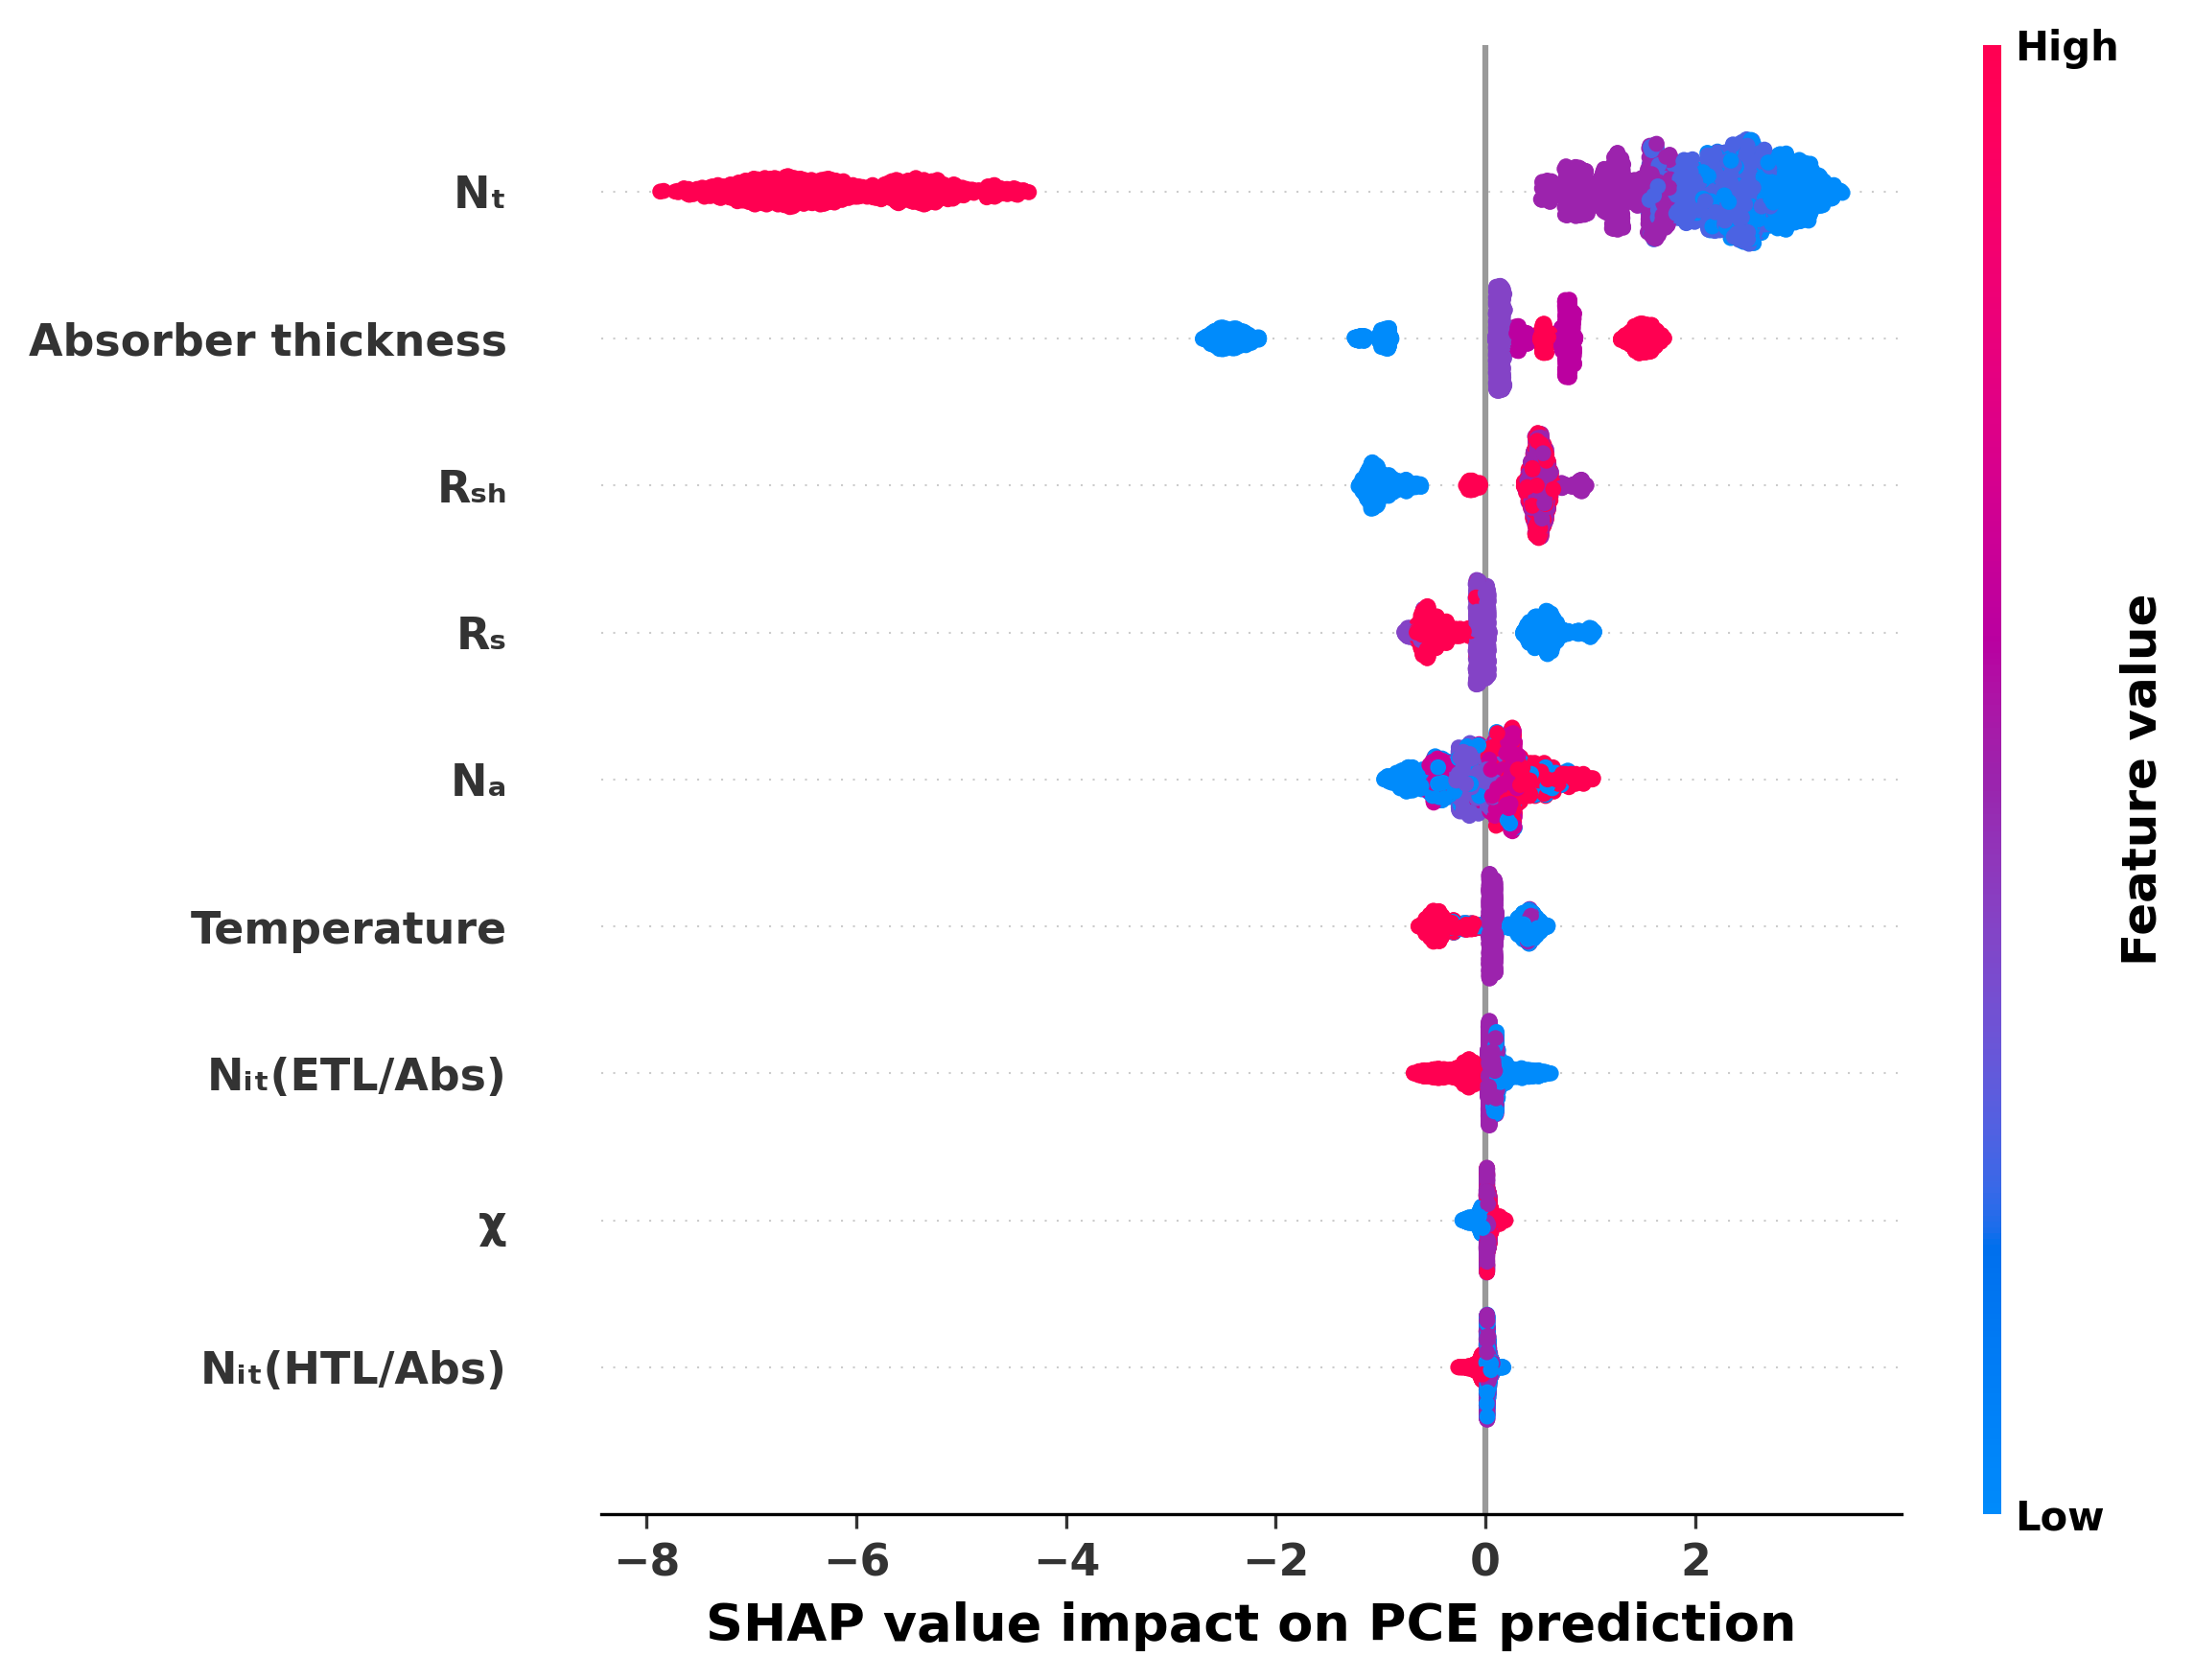

In [ ]:
# Q1-style SHAP summary plot for PCE prediction using XGBR

import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

# Sample test data for faster SHAP calculation
X_shap = X_test.sample(n=3000, random_state=42)

# SHAP calculation
explainer = shap.TreeExplainer(xgbr_pce_model)
shap_values = explainer.shap_values(X_shap)

# Publication-style feature labels
feature_name_map = {
    "Nt": "Nₜ",
    "x": "χ",
    "Na": "Nₐ",
    "Absorber_thickness": "Absorber thickness",
    "ETL_Abs_interface": "Nᵢₜ(ETL/Abs)",
    "HTL_Abs_interface": "Nᵢₜ(HTL/Abs)",
    "T": "Temperature",
    "Rs": "Rₛ",
    "Rsh": "Rₛₕ"
}

X_shap_display = X_shap.rename(columns=feature_name_map)

# Font settings compatible with Google Colab
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.size"] = 12
mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"

# Create SHAP figure
plt.figure(figsize=(8, 6), dpi=300)

shap.summary_plot(
    shap_values,
    X_shap_display,
    show=False,
    max_display=9,
    plot_size=None
)

ax = plt.gca()

# Bold x-axis label
ax.set_xlabel(
    "SHAP value impact on PCE prediction",
    fontsize=13,
    fontweight="bold"
)

# Bold x and y tick labels
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(11)

# Bold colorbar label and ticks
fig = plt.gcf()
for axis in fig.axes:
    if axis != ax:
        axis.set_ylabel(
            "Feature value",
            fontsize=12,
            fontweight="bold"
        )
        for label in axis.get_yticklabels():
            label.set_fontweight("bold")
            label.set_fontsize(10)

plt.tight_layout()
plt.savefig("Fig_SHAP_Summary_PCE_XGBR_Q1.png", dpi=1200, bbox_inches="tight")
plt.show()

feature Importance Plot

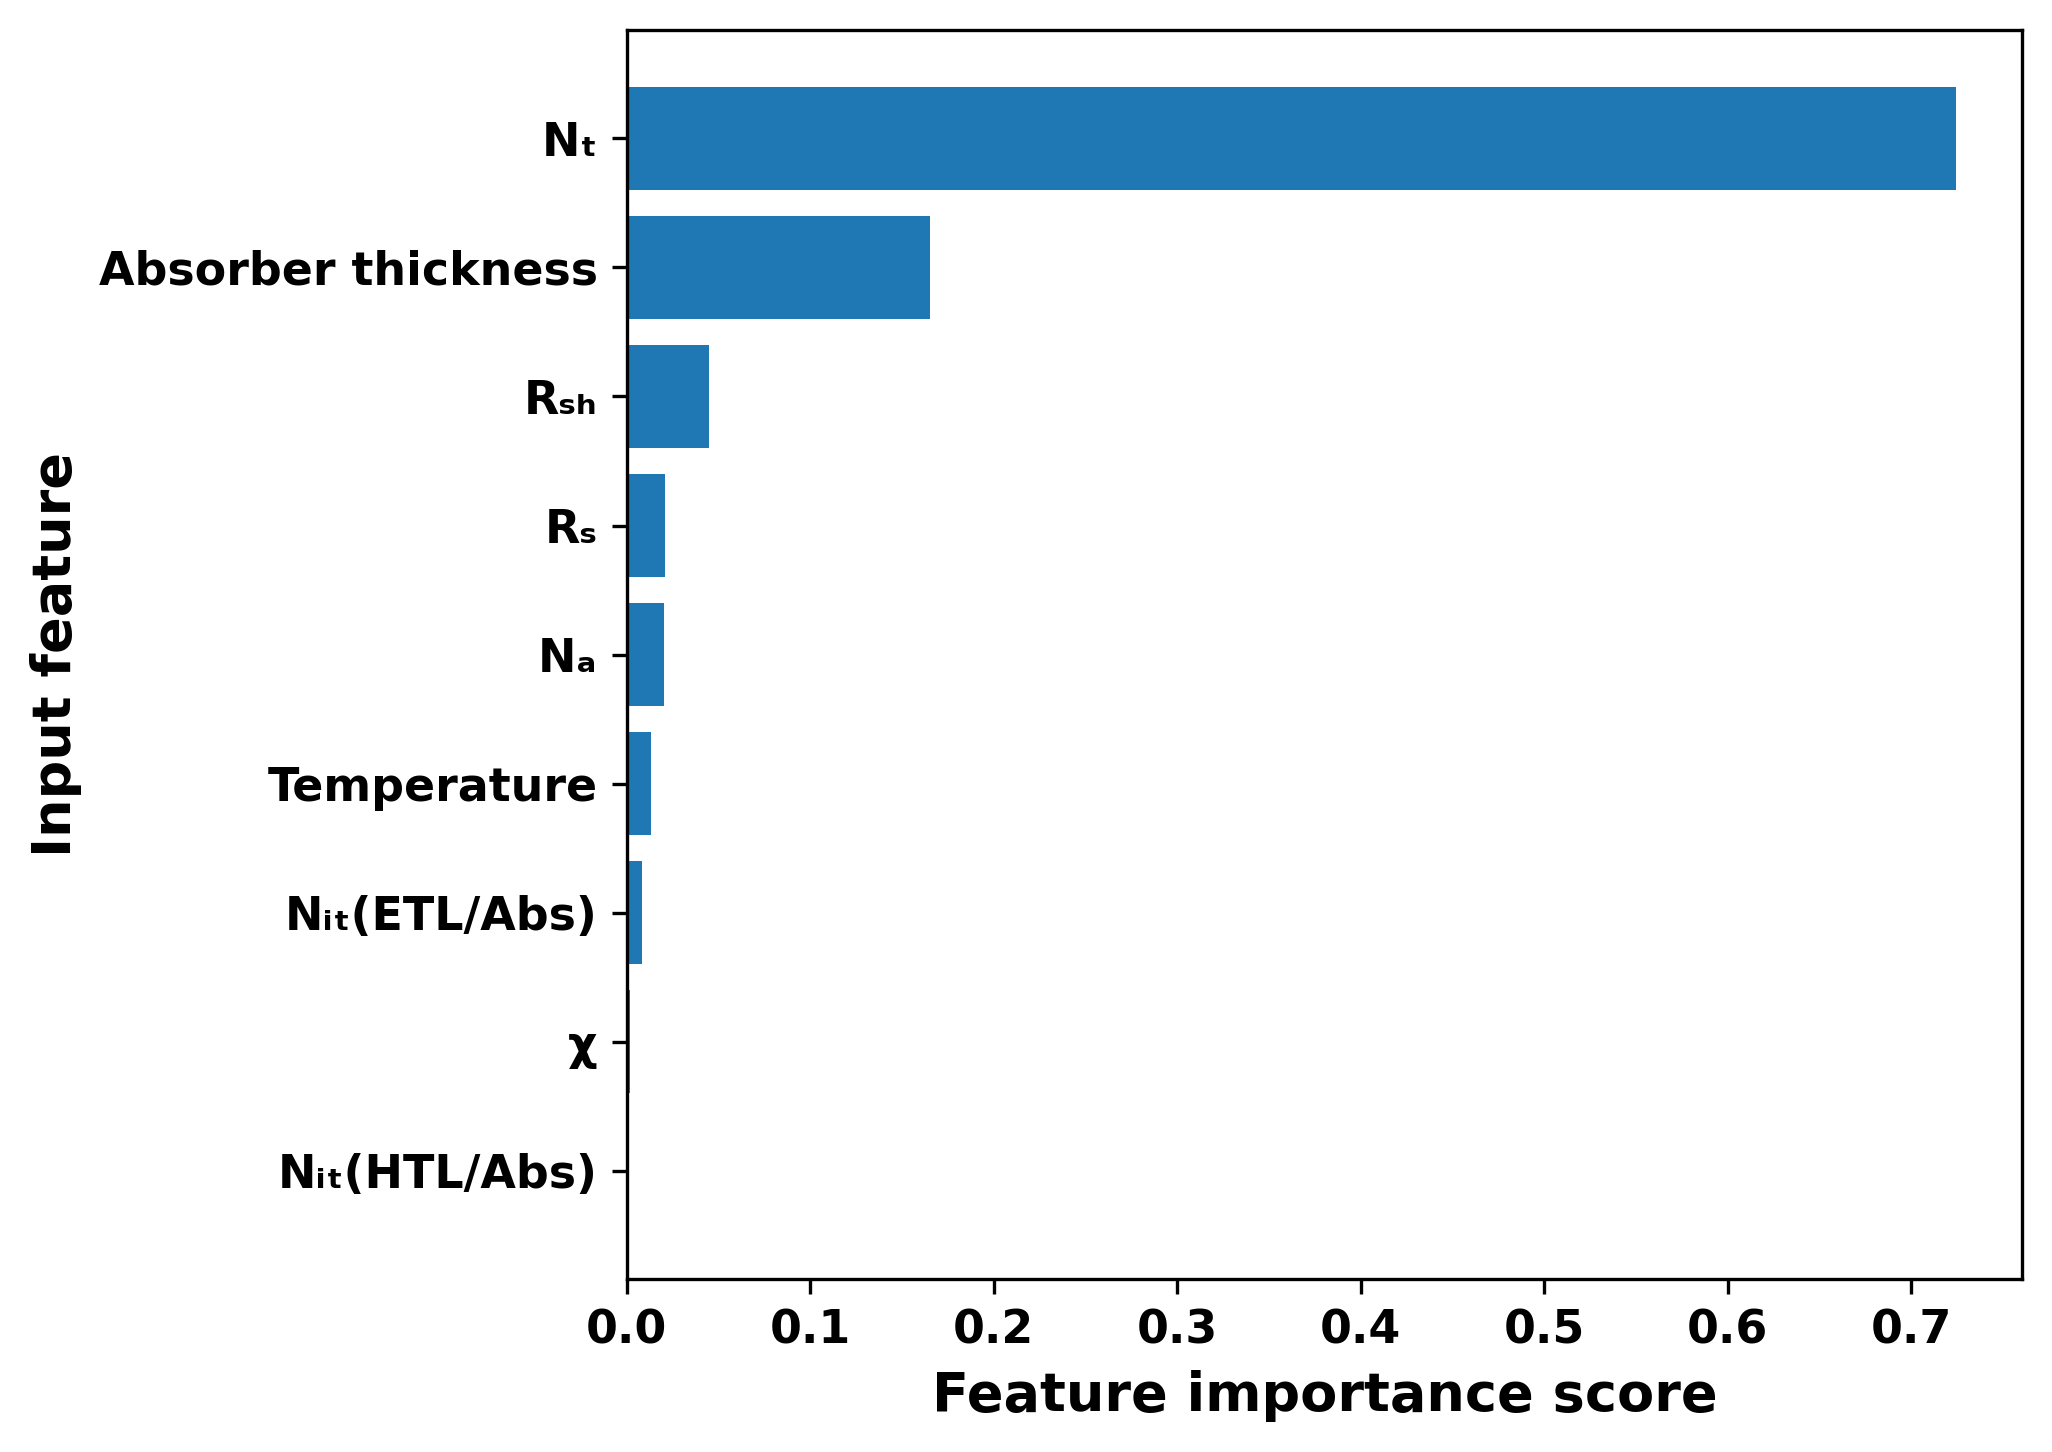

,Feature,Importance
0,Nₜ,0.724127
3,Absorber thickness,0.165433
8,Rₛₕ,0.045051
7,Rₛ,0.020682
2,Nₐ,0.020389
6,Temperature,0.013202
4,Nᵢₜ(ETL/Abs),0.008349
1,χ,0.001574
5,Nᵢₜ(HTL/Abs),0.001191


In [ ]:
# Optional feature-importance bar plot for PCE prediction using XGBR
# Use only if needed for supplementary material

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Publication-style labels
feature_name_map = {
    "Nt": "Nₜ",
    "x": "χ",
    "Na": "Nₐ",
    "Absorber_thickness": "Absorber thickness",
    "ETL_Abs_interface": "Nᵢₜ(ETL/Abs)",
    "HTL_Abs_interface": "Nᵢₜ(HTL/Abs)",
    "T": "Temperature",
    "Rs": "Rₛ",
    "Rsh": "Rₛₕ"
}

# Extract XGBR feature importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgbr_pce_model.feature_importances_
})

importance_df["Feature"] = importance_df["Feature"].map(feature_name_map)
importance_df = importance_df.sort_values("Importance", ascending=True)

# Font settings compatible with Colab
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.size"] = 12
mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"

plt.figure(figsize=(7, 5), dpi=300)

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature importance score", fontsize=13, fontweight="bold")
plt.ylabel("Input feature", fontsize=13, fontweight="bold")

ax = plt.gca()

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig("Supplementary_Feature_Importance_PCE_XGBR.png", dpi=1200, bbox_inches="tight")
plt.show()

importance_df.sort_values("Importance", ascending=False)

## Step 20: ML-Predicted Optimized Device Condition

The trained XGBR model is used to identify the input parameter combination that gives the highest predicted PCE within the simulated design space.

In [ ]:
# Predict PCE for all simulated device configurations using trained XGBR model

X_all = X.copy()

df_ml["PCE_ML_predicted"] = xgbr_pce_model.predict(X_all)

best_idx = df_ml["PCE_ML_predicted"].idxmax()

best_condition_original = df.loc[best_idx]
best_condition_ml = df_ml.loc[best_idx]

print("Best ML-predicted condition index:", best_idx)
print("\nBest condition in original SCAPS input scale:")
best_condition_original[features + targets]

Best ML-predicted condition index: 5094

Best condition in original SCAPS input scale:


,5094
Nt,1.000000e+12
x,3.610000e+00
Na,1.000000e+19
Absorber_thickness,8.000000e-01
ETL_Abs_interface,1.000000e+10
HTL_Abs_interface,1.000000e+10
T,3.000000e+02
Rs,0.000000e+00
Rsh,1.000000e+05
Voc,1.660462e+00


## Step 21: Optimized Input Parameters for SCAPS-1D Re-Simulation

The optimized input parameters are extracted in their original physical scale so that the same condition can be re-simulated in SCAPS-1D.

In [ ]:
# Extract optimized input parameters in original physical scale

optimized_inputs = best_condition_original[features]

optimized_inputs_df = pd.DataFrame({
    "Input parameter": optimized_inputs.index,
    "Optimized value": optimized_inputs.values
})

optimized_inputs_df

,Input parameter,Optimized value
0,Nt,1.000000e+12
1,x,3.610000e+00
2,Na,1.000000e+19
3,Absorber_thickness,8.000000e-01
4,ETL_Abs_interface,1.000000e+10
5,HTL_Abs_interface,1.000000e+10
6,T,3.000000e+02
7,Rs,0.000000e+00
8,Rsh,1.000000e+05


## Step 22: ML-Predicted and Dataset SCAPS Output at Optimized Condition

The ML-predicted PCE is compared with the corresponding SCAPS-1D output available in the dataset before manual SCAPS re-simulation.

In [ ]:
# Compare ML-predicted PCE with corresponding SCAPS output from dataset

optimized_output_summary = pd.DataFrame({
    "Photovoltaic parameter": ["Vₒc (V)", "Jₛc (mA cm⁻²)", "FF (%)", "PCE (%)"],
    "SCAPS dataset value": [
        best_condition_original["Voc"],
        best_condition_original["Jsc"],
        best_condition_original["FF"],
        best_condition_original["PCE"]
    ],
    "ML-predicted value": [
        np.nan,
        np.nan,
        np.nan,
        df_ml.loc[best_idx, "PCE_ML_predicted"]
    ]
})

optimized_output_summary

,Photovoltaic parameter,SCAPS dataset value,ML-predicted value
0,Vₒc (V),1.660462,NaN
1,Jₛc (mA cm⁻²),17.952480,NaN
2,FF (%),91.353700,NaN
3,PCE (%),27.232000,27.147774


## Step 23: Save ML-Predicted Optimized Condition

The optimized input parameters and corresponding output values are saved for SCAPS-1D validation.

In [ ]:
# Save optimized condition for SCAPS-1D validation

with pd.ExcelWriter("ML_Predicted_Optimized_Condition_for_SCAPS.xlsx") as writer:
    optimized_inputs_df.to_excel(writer, sheet_name="Optimized Inputs", index=False)
    optimized_output_summary.to_excel(writer, sheet_name="Output Summary", index=False)

from google.colab import files
files.download("ML_Predicted_Optimized_Condition_for_SCAPS.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Predict Voc, Jsc, FF, and PCE for the optimized condition

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# Optimized condition in original scale
optimized_condition = pd.DataFrame({
    "Nt": [1e12],
    "x": [3.61],
    "Na": [1e19],
    "Absorber_thickness": [0.80],
    "ETL_Abs_interface": [1e10],
    "HTL_Abs_interface": [1e10],
    "T": [300],
    "Rs": [0],
    "Rsh": [1e5]
})

# Apply same log10 transformation used during preprocessing
optimized_condition_ml = optimized_condition.copy()

for col in ["Nt", "Na", "ETL_Abs_interface", "HTL_Abs_interface", "Rsh"]:
    optimized_condition_ml[col] = np.log10(optimized_condition_ml[col])

# Define target-specific final models
final_target_models = {
    "Voc": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "Jsc": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "FF": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "PCE": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# Train each target-specific model and predict optimized output
ml_optimized_predictions = {}

for target, model in final_target_models.items():
    model.fit(X_train, Y_train[target])
    ml_optimized_predictions[target] = model.predict(optimized_condition_ml)[0]

ml_optimized_predictions_df = pd.DataFrame({
    "Photovoltaic parameter": ["Vₒc (V)", "Jₛc (mA cm⁻²)", "FF (%)", "PCE (%)"],
    "ML-predicted value": [
        ml_optimized_predictions["Voc"],
        ml_optimized_predictions["Jsc"],
        ml_optimized_predictions["FF"],
        ml_optimized_predictions["PCE"]
    ]
})

ml_optimized_predictions_df

,Photovoltaic parameter,ML-predicted value
0,Vₒc (V),1.656905
1,Jₛc (mA cm⁻²),17.949573
2,FF (%),91.311994
3,PCE (%),27.147774
